# <b><font color='lightcoral'>Метрики оценки модели</font></b>

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, \
                            confusion_matrix, \
                            precision_recall_curve, \
                            precision_score, \
                            recall_score, \
                            classification_report, f1_score

### <b><font color='lightcoral'>1. Accuracy</font></b>

In [11]:
from sklearn.datasets import load_iris

In [31]:
# Загрузите набор данных iris в переменную iris
iris = load_iris(as_frame=True)
df_iris = iris.frame
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [32]:
# Определите переменные независимые (X) и зависимые (y)
X = iris.data
y = iris.target


In [33]:
# Разделите данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Инициализируйте модель дерева решений
model_iris = DecisionTreeClassifier(random_state=42)

In [35]:
# Обучите модель на обучающих данных
model_iris.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [36]:
# Сделайте прогнозы на тестовом наборе
y_pred = model_iris.predict(X_test)

In [37]:
# Вычислите точность (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


In [38]:
# Отображение матрицы ошибок (prediction matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print('Матрица ошибок:')
print(conf_matrix)

Матрица ошибок:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


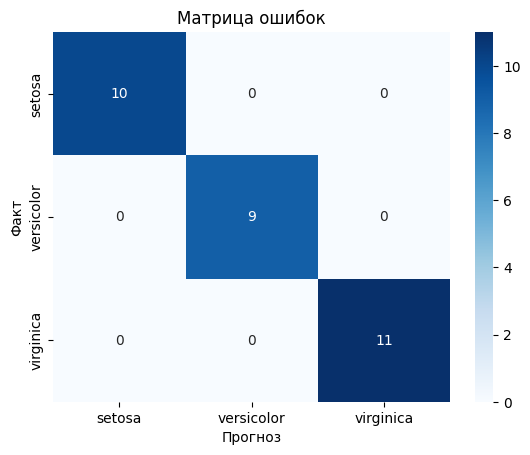

In [39]:
# Визуализация матрицы ошибок
sns.heatmap(conf_matrix, 
            annot = True, 
            fmt = 'd', 
            cmap = 'Blues', 
            xticklabels = iris.target_names, 
            yticklabels = iris.target_names)
plt.xlabel('Прогноз')
plt.ylabel('Факт')
plt.title('Матрица ошибок')
plt.show()

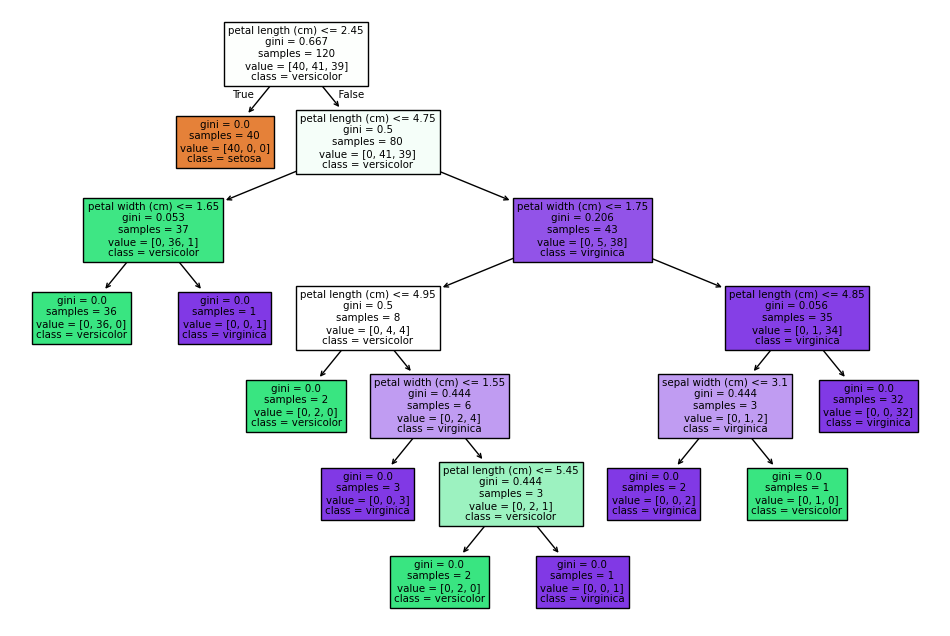

In [53]:
plt.figure(figsize = (12, 8))
plot_tree(model_iris, feature_names = iris.feature_names, class_names = iris.target_names, filled = True)
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

### <b><font color='lightcoral'>2. Precision-Recall</font></b>

In [42]:
# Загрузите данные в переменную df_bancing
df_bancing = pd.read_csv('../data/Banking.csv')
df_bancing.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,999,0,nonexistent,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,999,1,failure,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,999,0,nonexistent,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,999,0,nonexistent,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,999,0,nonexistent,no


In [43]:
df_bancing['y'].value_counts()

y
no     29238
yes     3712
Name: count, dtype: int64

In [44]:
# Предобработка данных
df_bancing['job_code'] = pd.factorize(df_bancing['job'])[0]
df_bancing['marital_code'] = pd.factorize(df_bancing['marital'])[0]
df_bancing['education_code'] = pd.factorize(df_bancing['education'])[0]
df_bancing['contact_code'] = pd.factorize(df_bancing['contact'])[0]
df_bancing['housing_code'] = pd.factorize(df_bancing['housing'])[0]
df_bancing['loan_code'] = pd.factorize(df_bancing['loan'])[0]
df_bancing['month'] = df_bancing['month'].replace({'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9,
                                                   'oct':10, 'nov':11, 'dec':12}).astype(int)
df_bancing['day_of_week'] = df_bancing['day_of_week'].replace({'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri':5}).astype(int)
df_bancing['y'] = df_bancing['y'].replace({'no':0, 'yes':1})

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_19288\64260085.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bancing['month'] = df_bancing['month'].replace({'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9,
C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_19288\64260085.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bancing['day_of_week'] = df_bancing['day_of_week'].replace({'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri':5}).astype(int)
C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_19288\64260085.py:11: Future

In [45]:
df_bancing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32950 non-null  int64 
 1   job             32950 non-null  object
 2   marital         32950 non-null  object
 3   education       32950 non-null  object
 4   default         32950 non-null  object
 5   housing         32950 non-null  object
 6   loan            32950 non-null  object
 7   contact         32950 non-null  object
 8   month           32950 non-null  int64 
 9   day_of_week     32950 non-null  int64 
 10  duration        32950 non-null  int64 
 11  campaign        32950 non-null  int64 
 12  pdays           32950 non-null  int64 
 13  previous        32950 non-null  int64 
 14  poutcome        32950 non-null  object
 15  y               32950 non-null  int64 
 16  job_code        32950 non-null  int64 
 17  marital_code    32950 non-null  int64 
 18  educat

In [46]:
# Определяем переменные-предикторы (X) и переменные-ответы (y)
X = df_bancing[['age', 'job_code', 'marital_code', 'education_code', 'housing_code', 'loan_code', 'contact_code', 
               'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']]
y = df_bancing['y']

In [47]:
# Разделите данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [48]:
# Инициализируйте модель дерево решений и логистическая регрессия
model_log_regr = LogisticRegression()
model_dec_tree = DecisionTreeClassifier()

In [49]:
# Обучите модели на обучающих данных
model_log_regr.fit(X_train, y_train)
model_dec_tree.fit(X_train, y_train)

c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
# Сделайте предсказания на тестовом наборе
y_pred_log_regr = model_log_regr.predict(X_test)
y_scores_log_regr = model_log_regr.predict_proba(X_test)[:, 1]
y_pred_dec_tree = model_dec_tree.predict(X_test)
y_scores_dec_tree = model_dec_tree.predict_proba(X_test)[:, 1]

In [55]:
model_log_regr.predict_proba(X_test)

array([[0.98218698, 0.01781302],
       [0.94966628, 0.05033372],
       [0.96120141, 0.03879859],
       ...,
       [0.99405993, 0.00594007],
       [0.95080288, 0.04919712],
       [0.76558752, 0.23441248]], shape=(6590, 2))

In [78]:
# Вычислите precision и recall и выведите результаты
precision_log_regr = precision_score(y_test, y_pred_log_regr)
recall_log_regr = recall_score(y_test, y_pred_log_regr)
print(f'Precision LogisticRegression: {precision_log_regr}')
print(f'Recall LogisticRegression: {recall_log_regr}')
precision_dec_tree = precision_score(y_test, y_pred_dec_tree)
recall_dec_tree = recall_score(y_test, y_pred_dec_tree)
print(f'Precision DecisionTree: {precision_dec_tree}')
print(f'Recall DecisionTree: {recall_dec_tree}')

Precision LogisticRegression: 0.6378504672897196
Recall LogisticRegression: 0.3446969696969697
Precision DecisionTree: 0.47701863354037266
Recall DecisionTree: 0.48484848484848486


In [68]:
# Выведите отчет о классификации
print('Отчет о классификации LogisticRegression:')
print(classification_report(y_test, y_pred_log_regr))
print('Отчет о классификации DecisionTree:')
print(classification_report(y_test, y_pred_dec_tree))

Отчет о классификации LogisticRegression:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5798
           1       0.64      0.34      0.45       792

    accuracy                           0.90      6590
   macro avg       0.78      0.66      0.70      6590
weighted avg       0.88      0.90      0.88      6590

Отчет о классификации DecisionTree:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5798
           1       0.48      0.48      0.48       792

    accuracy                           0.87      6590
   macro avg       0.70      0.71      0.70      6590
weighted avg       0.88      0.87      0.87      6590



In [69]:
# Выведите матрицу ошибок
conf_matrix_log_regr = confusion_matrix(y_test, y_pred_log_regr)
print('Матрица ошибок LogisticRegression:')
print(conf_matrix_log_regr)
conf_matrix_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
print('Матрица ошибок DecisionTree:')
print(conf_matrix_dec_tree)

Матрица ошибок LogisticRegression:
[[5643  155]
 [ 519  273]]
Матрица ошибок DecisionTree:
[[5377  421]
 [ 408  384]]


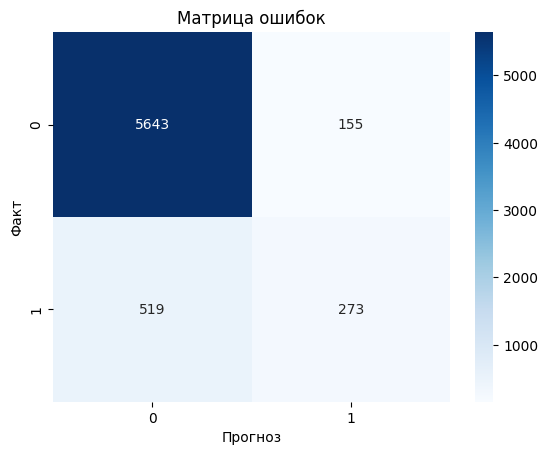

In [70]:
# Визуализируйте матрицу ошибок
sns.heatmap(conf_matrix_log_regr, 
            annot = True,
            fmt = 'd',
            cmap = 'Blues')
plt.xlabel('Прогноз')
plt.ylabel('Факт')
plt.title('Матрица ошибок')
plt.show()

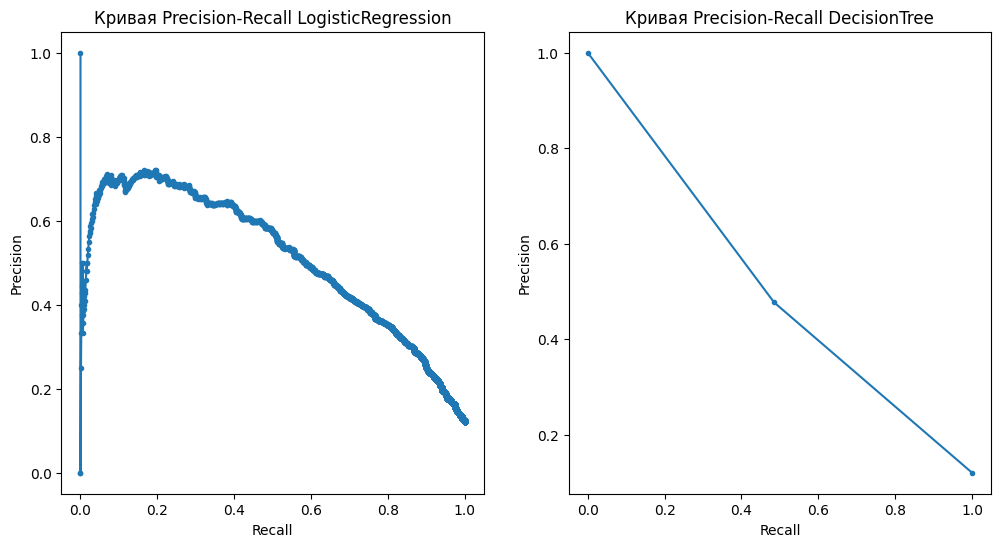

In [71]:
# Постройте кривую «Precision-Recall».
# 1. Рассчитайте кривую Precision-Recall
precisions_log_regr, recalls_log_regr, thresholds_log_regr = precision_recall_curve(y_test, y_scores_log_regr)
precisions_dec_tree, recalls_dec_tree, thresholds_dec_tree = precision_recall_curve(y_test, y_scores_dec_tree)
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
# 2. Построить график кривой Precision-Recall
plt.plot(recalls_log_regr, precisions_log_regr, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Кривая Precision-Recall LogisticRegression')

plt.subplot(1, 2, 2)
# 2. Построить график кривой Precision-Recall
plt.plot(recalls_dec_tree, precisions_dec_tree, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Кривая Precision-Recall DecisionTree')
plt.show()

### <b><font color='lightcoral'>3. Решение задач</font></b>

Примените алгоритм K-Nearest Neighbors (KNN) для классификации несбалансированного набора данных и вычисления F1-score. Мы будем использовать набор данных Breast Cancer из Scikit-learn, который является слегка несбалансированным.

In [112]:
# Импортируйте библиотеку для модели KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer


In [113]:
breast_cancer = load_breast_cancer(as_frame=True)
breast_cancer.frame.head()
X = breast_cancer.data
y = breast_cancer.target

In [114]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X, y, test_size=0.2, random_state=42)

In [115]:
# В переменную knn инициируйте модель KNN
# выберите количество соседей = 5
knn = KNeighborsClassifier(n_neighbors=5)


In [116]:
# Обучите модель
knn.fit(X_train_knn, y_train_knn)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [117]:
# Сделайте предсказания на тестовом наборе
y_pred_knn = knn.predict(X_test_knn)

In [118]:
# Вычислите precision, recall, f1_score в переменные с такими же названиями
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
print(f'Precision KNN: {precision_knn}')
print(f'Recall KNN: {recall_knn}')
print(f'F1 Score KNN: {f1_knn}')

Precision KNN: 0.9342105263157895
Recall KNN: 1.0
F1 Score KNN: 0.9659863945578231


Матрица ошибок KNN:
[[38  5]
 [ 0 71]]


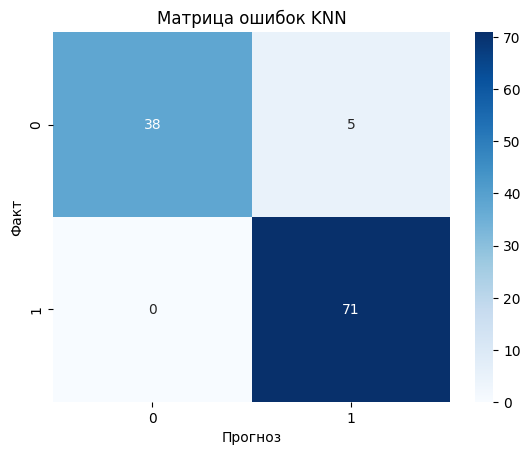

In [119]:
# Постройте матрицу ошибок и визуализируйте ее
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print('Матрица ошибок KNN:')
print(conf_matrix_knn)
sns.heatmap(conf_matrix_knn, 
            annot = True,
            fmt = 'd',
            cmap = 'Blues')
plt.xlabel('Прогноз')
plt.ylabel('Факт')
plt.title('Матрица ошибок KNN')
plt.show()